# Cat vs Dog Image Classification Using CNN

A Convolutional Neural Network (CNN) for binary image classification of cats and dogs using TensorFlow/Keras and data augmentation.

## 1. Connect Google Drive

In [72]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
import zipfile

zip_path = "/content/drive/MyDrive/CAT_DOG_CNN/cat_dog_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Dataset ZIP file is valid!")


Dataset ZIP file is valid!


In [114]:
import zipfile

zip_path = "/content/drive/MyDrive/CAT_DOG_CNN/cat_dog_dataset.zip"
extract_path = "/content/cat_dog_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## 2. Load and Inspect the Dataset

The dataset contains separate training and testing sets for two classes: cats and dogs.

Before loading the images, we inspect the extracted folder structure to verify that the dataset is organized correctly.

In [76]:
import os

dataset_path = "/content/cat_dog_dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

cat_dog_dataset/
    training_set/
        training_set/
            dogs/
            cats/
    test_set/
        test_set/
            dogs/
            cats/


In [77]:
import os

base_path = "/content/cat_dog_dataset"

folders = [
    "training_set/training_set/cats",
    "training_set/training_set/dogs",
    "test_set/test_set/cats",
    "test_set/test_set/dogs"
]

for folder in folders:
    path = os.path.join(base_path, folder)
    images = os.listdir(path)
    print(folder, ":", len(images), "images")

training_set/training_set/cats : 4001 images
training_set/training_set/dogs : 4006 images
test_set/test_set/cats : 1012 images
test_set/test_set/dogs : 1013 images


### Define Training and Testing Paths

The training and testing directories are defined so that the images can be loaded into the CNN model.

In [78]:
train_dir = "/content/cat_dog_dataset/training_set/training_set"
test_dir = "/content/cat_dog_dataset/test_set/test_set"

print("Training path:", train_dir)
print("Test path:", test_dir)

Training path: /content/cat_dog_dataset/training_set/training_set
Test path: /content/cat_dog_dataset/test_set/test_set


### Load Images Using Keras

The images are loaded directly from the training and testing directories using Keras. Each image is resized to 128 × 128 pixels and the images are processed in batches of 32.

The training dataset is shuffled to improve learning, while the test dataset is not shuffled to maintain a consistent evaluation order.

In [79]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


### Visualize Sample Images

A batch of training images is displayed to verify that the images are loaded correctly and that the corresponding class labels are assigned properly.

Classes: ['cats', 'dogs']


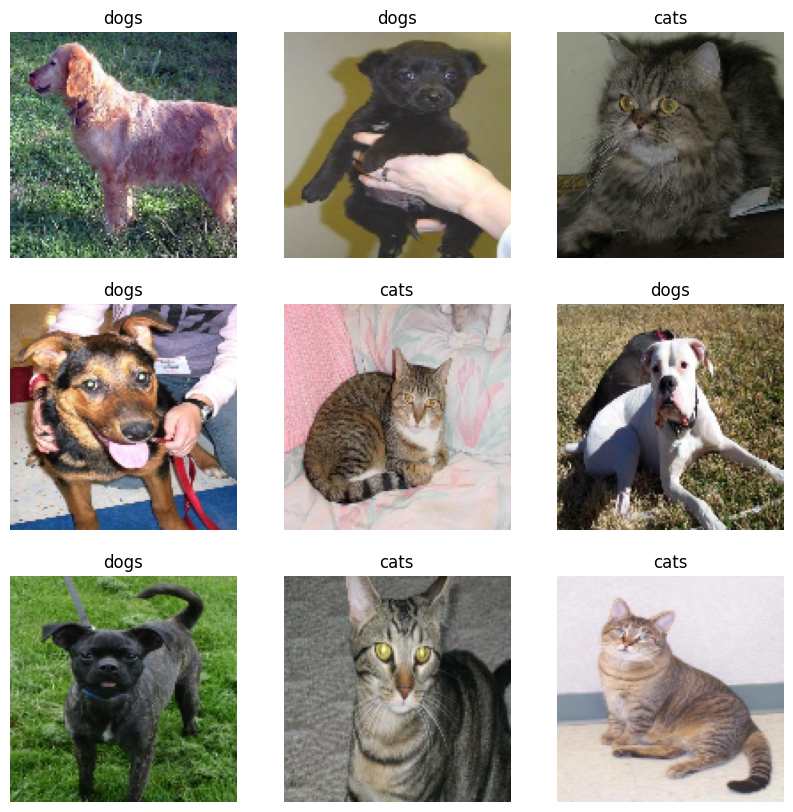

In [115]:
import matplotlib.pyplot as plt

class_names = train_data.class_names

print("Classes:", class_names)

for images, labels in train_data.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

    plt.show()

## 3. Data Augmentation

Data augmentation is used to create slightly different versions of the training images by applying random transformations. This helps the CNN learn features that are more general and reduces the risk of overfitting.

The following transformations are applied:
- Horizontal flipping
- Random rotation
- Random zoom

In [116]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

### Visualize Augmented Images

The augmentation layer is applied to sample training images to visualize the transformations. The images may be flipped, rotated, or zoomed randomly while retaining their original class labels.

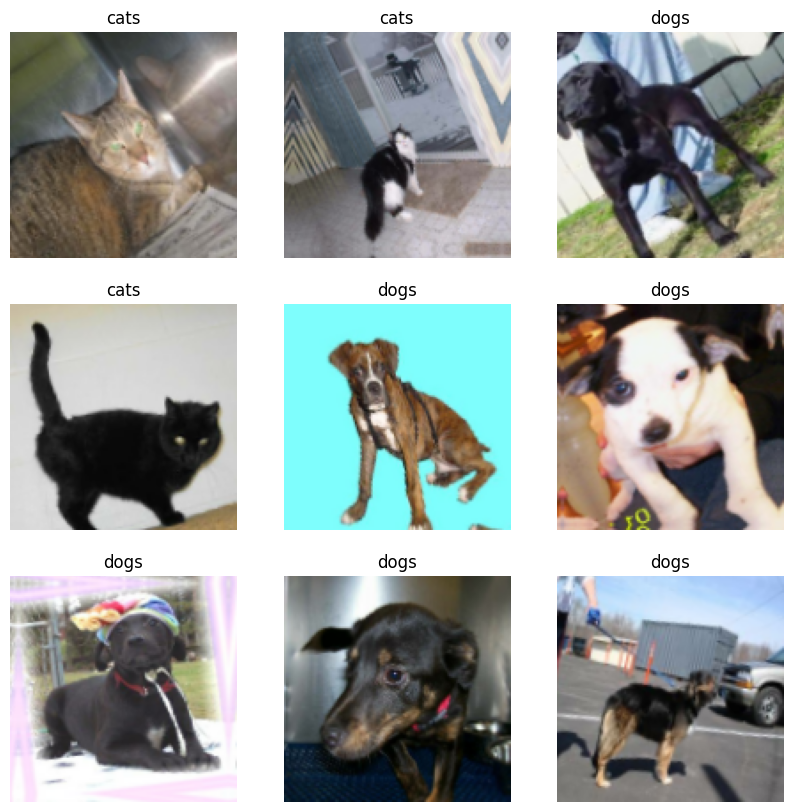

In [117]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        augmented_image = data_augmentation(images[i])

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

### Normalize Pixel Values

Image pixels normally have values between 0 and 255. The `Rescaling(1./255)` layer converts these values to a range between 0 and 1.

This helps the neural network train more efficiently and improves numerical stability.

In [84]:
normalization_layer = layers.Rescaling(1./255)

## 4. Build the CNN Model

A Convolutional Neural Network (CNN) is built to learn visual features from the cat and dog images.

The model first performs data augmentation and pixel normalization. It then uses convolutional layers to extract important image features such as edges, textures, and shapes.

### Input and Preprocessing

The input images have a size of 128 × 128 pixels with 3 color channels (RGB). Data augmentation and normalization are applied before feature extraction.

In [85]:
model = tf.keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    normalization_layer,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

### CNN Architecture

The CNN consists of three convolutional layers with max-pooling layers, followed by a flattening layer and fully connected Dense layers. Dropout is used to reduce overfitting, and a sigmoid output layer is used for binary classification.

In [118]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Model Summary

The model summary shows the architecture of the CNN, including the layers, output shapes, and number of trainable parameters.

In [119]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

The CNN model is trained using the training dataset for 10 epochs. After each epoch, the model is evaluated on the validation dataset to monitor its performance on unseen images.

The training history is stored in the `history` variable, which will be used later to visualize training and validation accuracy and loss.

In [95]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.5312 - loss: 0.6921 - val_accuracy: 0.5868 - val_loss: 0.6792
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.6209 - loss: 0.6554 - val_accuracy: 0.6693 - val_loss: 0.6271
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.6722 - loss: 0.6068 - val_accuracy: 0.7064 - val_loss: 0.5668
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.6967 - loss: 0.5777 - val_accuracy: 0.7088 - val_loss: 0.5704
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 351s 1s/step - accuracy: 0.7250 - loss: 0.5491 - val_accuracy: 0.7306 - val_loss: 0.5381
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - accuracy: 0.7425 - loss: 0.5232 - val_accuracy: 0.7568 - val_loss: 0.5220
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.7585 - loss: 0.5003 - val_accuracy: 0.7696 - val_loss: 0.4927
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.7670 - loss: 0.4855 - val_accu

## 6. Training and Validation Results

The training history is visualized using accuracy and loss graphs. These graphs help us understand how the model's performance changes across epochs and whether the model is learning effectively.

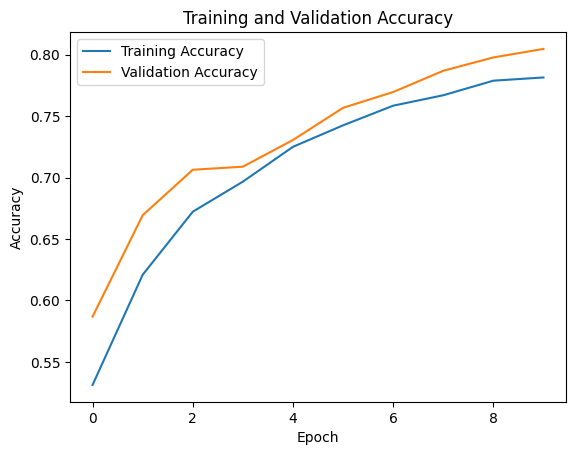

In [120]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.show()

### Training and Validation Accuracy

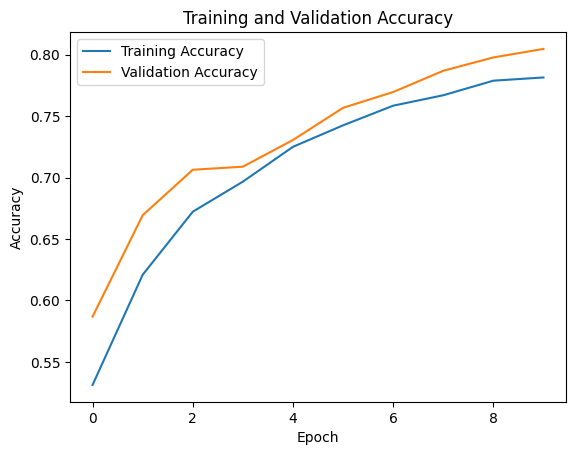

In [121]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.show()

## 7. Evaluate the Model

The trained CNN is evaluated on the test dataset to measure how well it performs on unseen images.

The evaluation provides:
- **Test Loss:** Measures the prediction error of the model.
- **Test Accuracy:** Shows the percentage of test images classified correctly.

In [100]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.8047 - loss: 0.4282
Test Loss: 0.42822250723838806
Test Accuracy: 0.8047454357147217


## 8. Confusion Matrix

A confusion matrix shows how many images were classified correctly and incorrectly for each class.

- **True Positive (TP):** Dogs correctly classified as dogs.
- **True Negative (TN):** Cats correctly classified as cats.
- **False Positive (FP):** Cats incorrectly classified as dogs.
- **False Negative (FN):** Dogs incorrectly classified as cats.

Confusion Matrix:
[[818 193]
 [202 810]]


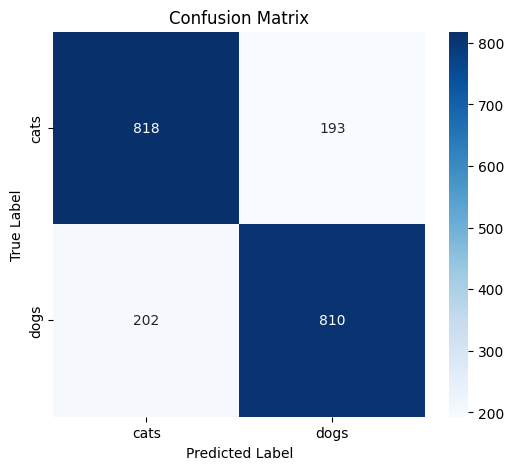

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



## 9. Classification Report

The classification report provides the **precision, recall, and F1-score** for each class.

- **Precision:** Of the images predicted as a particular class, how many were actually that class.
- **Recall:** Of all actual images of a class, how many were correctly identified.
- **F1-score:** The balance between precision and recall.
- **Support:** The number of actual images belonging to each class.

In [122]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        cats       0.80      0.81      0.81      1011
        dogs       0.81      0.80      0.80      1012

    accuracy                           0.80      2023
   macro avg       0.80      0.80      0.80      2023
weighted avg       0.80      0.80      0.80      2023



## 10. Test the Model on New Images

The trained CNN is tested on new images that were not used during training or evaluation. This demonstrates how the model performs on individual unseen images.

In [105]:
image_path = '/content/cat1.jpg'

In [123]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img = load_img(image_path, target_size=(128, 128))

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("Predicted: Dog 🐶")
else:
    print("Predicted: Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Prediction: [[0.00325483]]
Predicted: Cat 🐱


### Test with a Dog Image

In [108]:
image1_path = '/content/dog1.jpg'

In [124]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img = load_img(image1_path, target_size=(128, 128))

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction probability:", prediction)

if prediction[0][0] > 0.5:
    print("Predicted: Dog 🐶")
else:
    print("Predicted: Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Prediction probability: [[0.99106586]]
Predicted: Dog 🐶
